In [ ]:
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
df = pd.read_csv(r"d:\Churn prediction\data\churn_features.csv")
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,True,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,False,...,False,True,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,False,...,True,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,False,...,False,True,True,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)  # features
y = df['Churn']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8, 
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]  # probability for ROC-AUC

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[949  86]
 [187 187]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1035
           1       0.68      0.50      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8467410679686894


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[927 108]
 [176 198]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8365896819861014


c:\Users\unick\anaconda3\envs\myenv\lib\site-packages\xgboost\training.py:200: UserWarning: [01:49:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


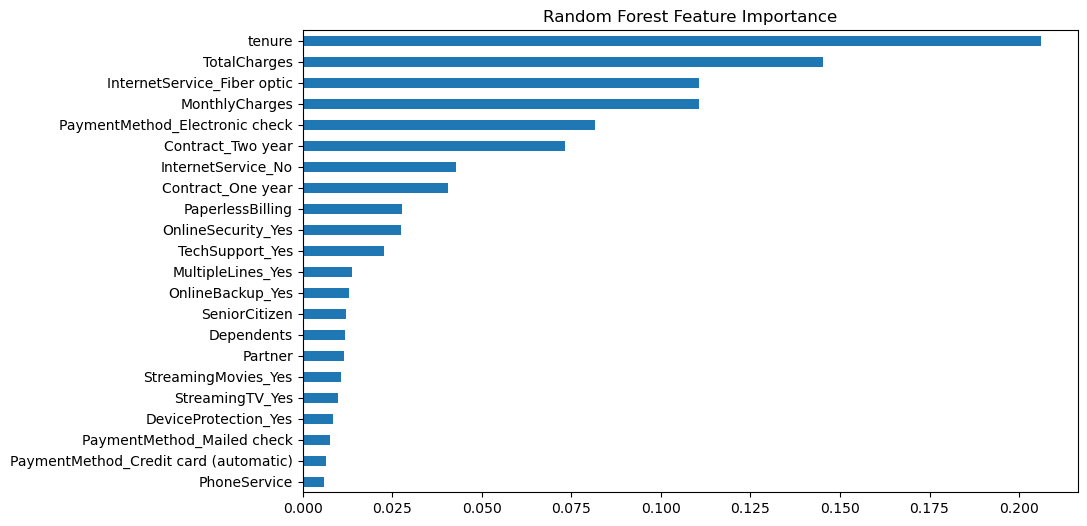

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
#hyperparameter tunning

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100,200,300],
    'max_depth': [5,8,12],
    'min_samples_split':[2,5,10]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=3, scoring='roc_auc')
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 300}
